<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-37-elasticnet-regression-regularization?scriptVersionId=344151747" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

<div style="background: linear-gradient(135deg, #0d1117 0%, #1c1f26 50%, #0d2137 100%); padding: 48px 40px; border-radius: 16px; margin-bottom: 8px; border: 1px solid #30363d;">
  <div style="display: flex; align-items: center; gap: 12px; margin-bottom: 16px;">
    <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 2px; padding: 4px 12px; border-radius: 20px; text-transform: uppercase;">ML Series · Episode 37</span>
  </div>
  <h1 style="color: #ffffff; font-size: 38px; font-weight: 800; margin: 0 0 12px 0; line-height: 1.2;">ᛝ ElasticNet Regression</h1>
  <p style="color: #8b949e; font-size: 17px; margin: 0 0 28px 0; max-width: 640px; line-height: 1.6;">The best of both worlds — combining L1 sparsity and L2 stability into a single regularizer that handles correlated features and high-dimensional data where Ridge and Lasso individually fall short.</p>
  <div style="display: flex; gap: 24px; flex-wrap: wrap;">
    <div style="background: rgba(255,255,255,0.05); border: 1px solid #30363d; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f0a500; font-size: 22px; font-weight: 700;">L1 + L2</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 2px;">Combined Penalty</div>
    </div>
    <div style="background: rgba(255,255,255,0.05); border: 1px solid #30363d; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f0a500; font-size: 22px; font-weight: 700;">l1_ratio</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 2px;">Mix Parameter (0→1)</div>
    </div>
    <div style="background: rgba(255,255,255,0.05); border: 1px solid #30363d; border-radius: 10px; padding: 14px 20px;">
      <div style="color: #f0a500; font-size: 22px; font-weight: 700;">sklearn</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 2px;">ElasticNet · ElasticNetCV</div>
    </div>
  </div>
</div>

<div style="background: #161b22; border-left: 5px solid #f0a500; border-radius: 0 10px 10px 0; padding: 20px 24px; margin: 24px 0; border: 1px solid #30363d; border-left: 5px solid #f0a500;">
  <h2 style="color: #f0a500; font-size: 15px; font-weight: 700; text-transform: uppercase; letter-spacing: 1.5px; margin: 0 0 10px 0;">📋 Table of Contents</h2>
  <ol style="margin: 0; padding-left: 20px; color: #58a6ff; line-height: 2; font-size: 14px;">
    <li><a href='#concept' style='color: #58a6ff; text-decoration: none;'>Why ElasticNet? — The Problem with Ridge &amp; Lasso Alone</a></li>
    <li><a href='#imports' style='color: #58a6ff; text-decoration: none;'>Imports &amp; Setup</a></li>
    <li><a href='#data' style='color: #58a6ff; text-decoration: none;'>Dataset — High Correlation + High Dimensionality</a></li>
    <li><a href='#models' style='color: #58a6ff; text-decoration: none;'>All Four Models — OLS, Ridge, Lasso, ElasticNet</a></li>
    <li><a href='#compare' style='color: #58a6ff; text-decoration: none;'>Model Comparison — Scores &amp; Coefficients</a></li>
    <li><a href='#l1ratio' style='color: #58a6ff; text-decoration: none;'>Effect of l1_ratio — Sweeping from Ridge to Lasso</a></li>
    <li><a href='#alpha' style='color: #58a6ff; text-decoration: none;'>Effect of Alpha — Regularization Strength</a></li>
    <li><a href='#summary' style='color: #58a6ff; text-decoration: none;'>Summary &amp; When to Use ElasticNet</a></li>
  </ol>
</div>

<a id='concept'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 1</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Why ElasticNet? — The Problem with Ridge &amp; Lasso Alone</h2>
</div>

We've seen Ridge (L2) and Lasso (L1) each solve specific problems. But both have **blind spots**:

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 16px; margin: 20px 0;">
  <div style="background: #161b22; border: 1px solid #30363d; border-top: 3px solid #3498db; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #3498db; font-weight: 700; font-size: 14px; margin-bottom: 8px;">Ridge (L2) — Weakness</div>
    <div style="color: #8b949e; font-size: 13px; line-height: 1.7;">
      ❌ Cannot zero out coefficients — keeps all features<br/>
      ❌ Poor interpretability when most features are noise<br/>
      ✅ Great with correlated features — distributes weight evenly
    </div>
  </div>
  <div style="background: #161b22; border: 1px solid #30363d; border-top: 3px solid #c084fc; border-radius: 0 0 10px 10px; padding: 18px 20px;">
    <div style="color: #c084fc; font-weight: 700; font-size: 14px; margin-bottom: 8px;">Lasso (L1) — Weakness</div>
    <div style="color: #8b949e; font-size: 13px; line-height: 1.7;">
      ❌ Randomly picks one from correlated group, drops rest<br/>
      ❌ Selects at most n features when p &gt; n<br/>
      ✅ Great sparse models — automatic feature selection
    </div>
  </div>
</div>

**ElasticNet** combines both penalties with a mixing parameter `l1_ratio`:

<div style="background: #0d1117; border: 1px solid #30363d; border-radius: 12px; padding: 24px 32px; margin: 20px 0;">
  <div style="color: #8b949e; font-size: 11px; letter-spacing: 1.5px; text-transform: uppercase; margin-bottom: 14px;">ElasticNet Cost Function</div>
  <div style="color: #f0a500; font-size: 20px; font-weight: 700; font-family: Georgia, serif; text-align: center; margin-bottom: 16px;">
    J(θ) = MSE + α · ρ · Σ|θᵢ| + α · (1−ρ)/2 · Σθᵢ²
  </div>
  <div style="display: grid; grid-template-columns: 1fr 1fr 1fr; gap: 16px; margin-top: 8px;">
    <div style="text-align: center;">
      <div style="color: #f0a500; font-weight: 700; font-size: 14px;">α (alpha)</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">Overall regularization strength</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #f0a500; font-weight: 700; font-size: 14px;">ρ (l1_ratio)</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">Mix: 0 = pure Ridge, 1 = pure Lasso</div>
    </div>
    <div style="text-align: center;">
      <div style="color: #f0a500; font-weight: 700; font-size: 14px;">1 − ρ</div>
      <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">Ridge share of the penalty</div>
    </div>
  </div>
</div>

<div style="display: flex; gap: 12px; margin: 16px 0; flex-wrap: wrap;">
  <div style="flex: 1; min-width: 180px; background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 12px 16px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px;">l1_ratio = 0</div>
    <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">Pure Ridge — no zeros, full shrinkage</div>
  </div>
  <div style="flex: 1; min-width: 180px; background: #161b22; border: 1px solid #f0a500; border-radius: 8px; padding: 12px 16px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px;">0 &lt; l1_ratio &lt; 1 ✦</div>
    <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">ElasticNet — zeros noise, keeps correlated groups</div>
  </div>
  <div style="flex: 1; min-width: 180px; background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 12px 16px;">
    <div style="color: #f0a500; font-weight: 700; font-size: 13px;">l1_ratio = 1</div>
    <div style="color: #8b949e; font-size: 12px; margin-top: 4px;">Pure Lasso — sparse, but unstable with correlated features</div>
  </div>
</div>

<a id='imports'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 2</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Imports &amp; Setup</h2>
</div>

All four models — `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet` — are imported from `sklearn.linear_model`. We also bring in `ElasticNetCV` for automated hyperparameter search later.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, ElasticNetCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

<a id='data'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 3</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Dataset — High Correlation + High Dimensionality</h2>
</div>

We use `make_regression` with two critical parameters that create the scenario where ElasticNet shines:

<div style="background: #0d1117; border: 1px solid #30363d; border-radius: 12px; padding: 20px 28px; margin: 16px 0;">
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 20px; font-size: 13px;">
    <div>
      <div style="color: #f0a500; font-weight: 700; margin-bottom: 6px;">n_features=100, n_informative=50</div>
      <div style="color: #8b949e; line-height: 1.6;">100 features total, only 50 carry real signal. The other 50 are noise — Lasso should zero them, Ridge can't.</div>
    </div>
    <div>
      <div style="color: #f0a500; font-weight: 700; margin-bottom: 6px;">effective_rank=5</div>
      <div style="color: #8b949e; line-height: 1.6;">Forces high multicollinearity — many features are nearly linear combinations of just 5 underlying directions. This is where Lasso struggles and Ridge &amp; ElasticNet handle it better.</div>
    </div>
  </div>
</div>

In [2]:
X, y = make_regression(
    n_samples=100,
    n_features=100,      # 100 total features
    n_informative=50,    # 50 truly informative
    effective_rank=5,    # high multicollinearity
    noise=20,
    random_state=13
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Target range : [{y.min():.1f}, {y.max():.1f}]")

Train : (80, 100)  |  Test : (20, 100)
Target range : [-48.2, 65.3]


<div style="background: #161b22; border: 1px solid #30363d; border-radius: 8px; padding: 14px 18px; margin: 14px 0; font-size: 13px; color: #8b949e;">
  <strong style="color: #e6edf3;">⚙️ Why this dataset is challenging:</strong> With 100 samples and 100 features, we are at the boundary of the underdetermined regime — OLS has too many degrees of freedom and will massively overfit. The <code>effective_rank=5</code> constraint means many features are nearly identical linear combinations, so Lasso will arbitrarily pick one from each correlated group and discard the rest, losing information.
</div>

<a id='models'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 4</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">All Four Models — OLS, Ridge, Lasso, ElasticNet</h2>
</div>

We fit all four models on the same train/test split so results are directly comparable. Each model is a progression — from no regularization (OLS) to the combined penalty (ElasticNet).

In [3]:
# ── 1. Linear Regression (OLS — no penalty) ──────────────────────────────
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("OLS  R² :", round(r2_score(y_test, lr_pred), 4))

OLS  R² : -0.8015


In [4]:
# ── 2. Ridge (L2 penalty) ────────────────────────────────────────────────
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

print("Ridge R² :", round(r2_score(y_test, ridge_pred), 4))

Ridge R² : -0.0324


In [5]:
# ── 3. Lasso (L1 penalty) ────────────────────────────────────────────────
lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Lasso R² :", round(r2_score(y_test, lasso_pred), 4))
print(f"Non-zero coefs : {np.sum(lasso.coef_ != 0)} / {len(lasso.coef_)}")

Lasso R² : -0.6853
Non-zero coefs : 64 / 100


In [6]:
# ── 4. ElasticNet (L1 + L2 combined) ─────────────────────────────────────
# l1_ratio=0.9 → mostly Lasso-like, with a Ridge stabilizer
elastic = ElasticNet(alpha=0.01, l1_ratio=0.9)
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

print("ElasticNet R² :", round(r2_score(y_test, elastic_pred), 4))
print(f"Non-zero coefs  : {np.sum(elastic.coef_ != 0)} / {len(elastic.coef_)}")

ElasticNet R² : 0.1237
Non-zero coefs  : 86 / 100


<a id='compare'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 5</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Model Comparison — Scores &amp; Coefficients</h2>
</div>

Numbers alone don't tell the whole story. The coefficient plots below reveal *how* each model distributes weight across 100 features — OLS is chaotic, Ridge is dense, Lasso is sparse (possibly too sparse), and ElasticNet strikes the right balance.

In [7]:
# ── Score summary table ───────────────────────────────────────────────────
results = {
    'Model':       ['OLS', 'Ridge (α=10)', 'Lasso (α=0.01)', 'ElasticNet (α=0.01, ρ=0.9)'],
    'R²':          [r2_score(y_test, lr_pred),
                    r2_score(y_test, ridge_pred),
                    r2_score(y_test, lasso_pred),
                    r2_score(y_test, elastic_pred)],
    'RMSE':        [np.sqrt(mean_squared_error(y_test, lr_pred)),
                    np.sqrt(mean_squared_error(y_test, ridge_pred)),
                    np.sqrt(mean_squared_error(y_test, lasso_pred)),
                    np.sqrt(mean_squared_error(y_test, elastic_pred))],
    'Non-zero θ':  [np.sum(lr.coef_ != 0),
                    np.sum(ridge.coef_ != 0),
                    np.sum(lasso.coef_ != 0),
                    np.sum(elastic.coef_ != 0)],
}
df = pd.DataFrame(results)
df['R²']   = df['R²'].round(4)
df['RMSE'] = df['RMSE'].round(2)
print(df.to_string(index=False))

                     Model      R²  RMSE  Non-zero θ
                       OLS -0.8015 32.63         100
              Ridge (α=10) -0.0324 24.70         100
            Lasso (α=0.01) -0.6853 31.56          64
ElasticNet (α=0.01, ρ=0.9)  0.1237 22.76          86


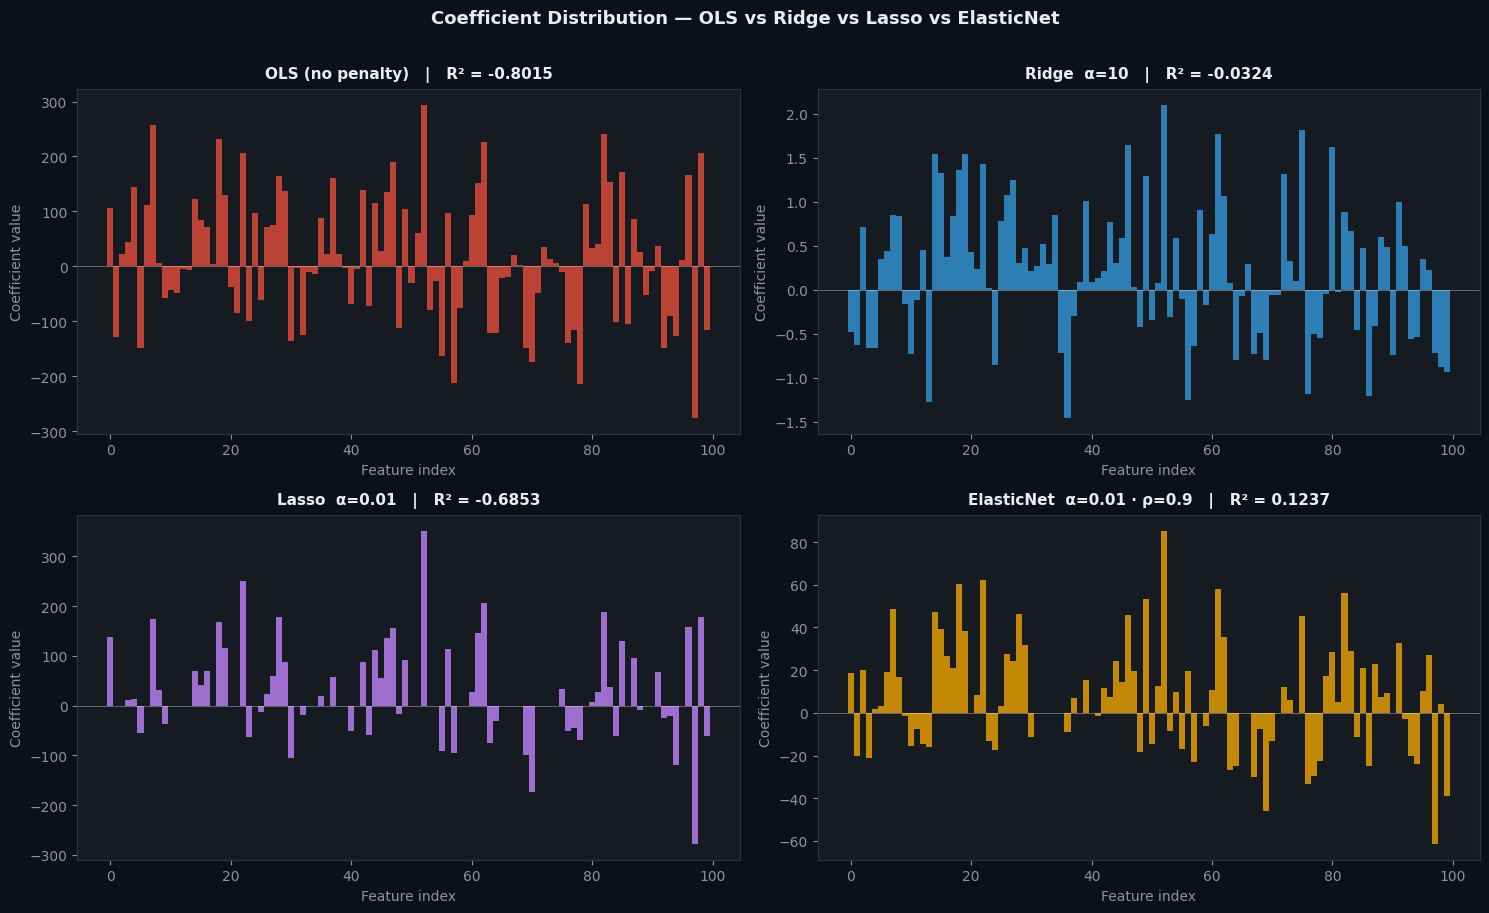

In [8]:
# ── Coefficient comparison — 4-panel plot ────────────────────────────────
models     = [lr, ridge, lasso, elastic]
names      = ['OLS (no penalty)', 'Ridge  α=10', 'Lasso  α=0.01', 'ElasticNet  α=0.01 · ρ=0.9']
bar_colors = ['#e74c3c', '#3498db', '#c084fc', '#f0a500']
scores     = [r2_score(y_test, p) for p in [lr_pred, ridge_pred, lasso_pred, elastic_pred]]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
fig.patch.set_facecolor('#0d1117')

for ax, model, name, color, score in zip(axes.ravel(), models, names, bar_colors, scores):
    ax.set_facecolor('#161b22')
    ax.bar(range(len(model.coef_)), model.coef_, color=color, alpha=0.8, width=1.0)
    ax.axhline(0, color='white', linewidth=0.6, alpha=0.4)
    ax.set_title(f'{name}   |   R² = {score:.4f}', color='#e6edf3', fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('Feature index', color='#8b949e', fontsize=10)
    ax.set_ylabel('Coefficient value', color='#8b949e', fontsize=10)
    ax.tick_params(colors='#8b949e')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')

plt.suptitle('Coefficient Distribution — OLS vs Ridge vs Lasso vs ElasticNet',
             color='#e6edf3', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

<div style="background: #161b22; border-left: 4px solid #f0a500; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #8b949e;">
  <strong style="color: #e6edf3;">✅ Reading the plots:</strong> OLS coefficients are wildly erratic — classic overfit with 100 features and 100 samples. Ridge compresses everything but keeps all 100. Lasso produces a sparse solution but may arbitrarily drop correlated features. ElasticNet combines both: it zeros noise features while distributing weight fairly within correlated groups.
</div>

<a id='l1ratio'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 6</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Effect of l1_ratio — Sweeping from Ridge to Lasso</h2>
</div>

`l1_ratio` is ElasticNet's most important knob. At `0` it's pure Ridge; at `1` it's pure Lasso. Every value in between blends both penalties. The plot below shows how R² and the number of non-zero coefficients change as we sweep `l1_ratio` from 0 to 1.

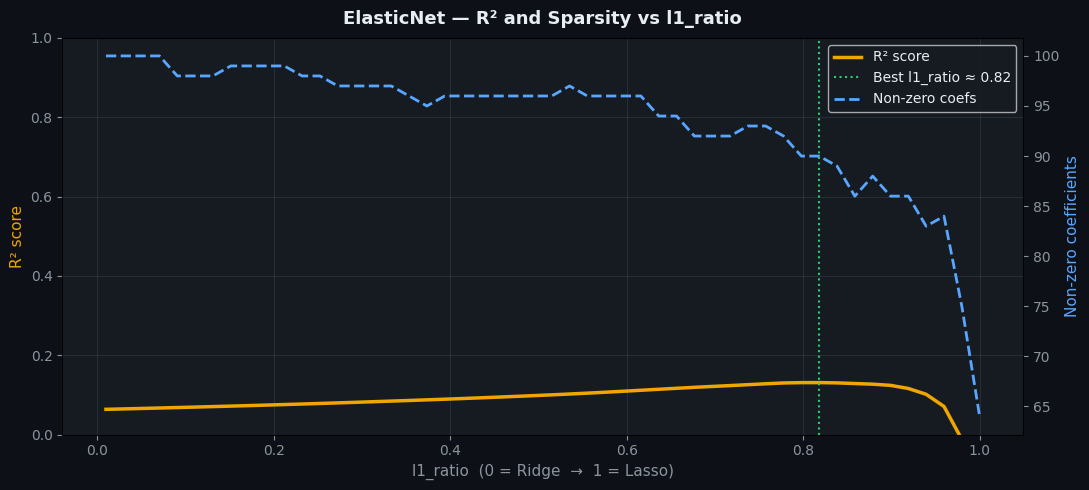

Best l1_ratio : 0.818
Best R²       : 0.1309
Non-zero coefs at best : 90


In [9]:
l1_ratios   = np.linspace(0.01, 1.0, 50)
r2_list     = []
nonzero_list = []

for ratio in l1_ratios:
    en = ElasticNet(alpha=0.01, l1_ratio=ratio, max_iter=5000)
    en.fit(X_train, y_train)
    r2_list.append(r2_score(y_test, en.predict(X_test)))
    nonzero_list.append(np.sum(en.coef_ != 0))

fig, ax1 = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor('#0d1117')
ax1.set_facecolor('#161b22')

ax1.plot(l1_ratios, r2_list, color='#f0a500', linewidth=2.5, label='R² score')
ax1.set_xlabel('l1_ratio  (0 = Ridge  →  1 = Lasso)', color='#8b949e', fontsize=11)
ax1.set_ylabel('R² score', color='#f0a500', fontsize=11)
ax1.tick_params(colors='#8b949e')
ax1.set_ylim(0, 1)

ax2 = ax1.twinx()
ax2.plot(l1_ratios, nonzero_list, color='#58a6ff', linewidth=2, linestyle='--', label='Non-zero coefs')
ax2.set_ylabel('Non-zero coefficients', color='#58a6ff', fontsize=11)
ax2.tick_params(colors='#8b949e')

# Best point
best_idx = np.argmax(r2_list)
ax1.axvline(l1_ratios[best_idx], color='#2ecc71', linewidth=1.5,
            linestyle=':', label=f'Best l1_ratio ≈ {l1_ratios[best_idx]:.2f}')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=10,
           facecolor='#161b22', labelcolor='#e6edf3')

for spine in ax1.spines.values():
    spine.set_edgecolor('#30363d')

ax1.set_title('ElasticNet — R² and Sparsity vs l1_ratio',
              color='#e6edf3', fontsize=13, fontweight='bold', pad=10)
ax1.grid(True, alpha=0.15, color='#8b949e')
plt.tight_layout()
plt.show()

print(f"Best l1_ratio : {l1_ratios[best_idx]:.3f}")
print(f"Best R²       : {max(r2_list):.4f}")
print(f"Non-zero coefs at best : {nonzero_list[best_idx]}")

<div style="background: #161b22; border-left: 4px solid #f0a500; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #8b949e;">
  <strong style="color: #e6edf3;">✅ Key insight:</strong> R² peaks at an intermediate l1_ratio — neither pure Ridge nor pure Lasso is optimal. The orange line (R²) and blue dashed line (non-zero coefs) move together: as more Lasso is added, the model becomes sparser. The green vertical line marks the sweet spot where both sparsity and accuracy are balanced.
</div>

<a id='alpha'></a>
<div style="border-bottom: 2px solid #f0a500; padding-bottom: 8px; margin: 32px 0 20px 0;">
  <span style="background: #f0a500; color: #0d1117; font-size: 11px; font-weight: 700; letter-spacing: 1.5px; padding: 3px 10px; border-radius: 4px; text-transform: uppercase;">Section 7</span>
  <h2 style="color: #e6edf3; font-size: 22px; font-weight: 700; margin: 10px 0 0 0;">Effect of Alpha — Regularization Strength</h2>
</div>

With `l1_ratio` fixed, `alpha` controls the overall strength of the penalty. Low alpha → weak regularization (approaches OLS). High alpha → heavy shrinkage (approaches zero). The heatmap below shows R² across a 2D grid of both hyperparameters simultaneously — a practical tool for understanding the full parameter landscape.

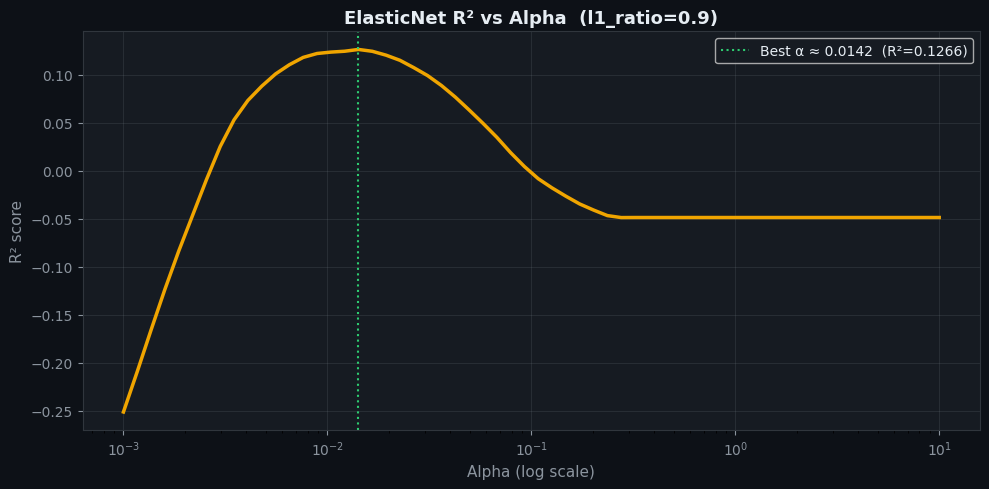

In [10]:
# ── R² vs Alpha (fixed l1_ratio = 0.9) ───────────────────────────────────
alphas   = np.logspace(-3, 1, 60)   # 0.001 to 10
r2_alpha = []

for a in alphas:
    en = ElasticNet(alpha=a, l1_ratio=0.9, max_iter=5000)
    en.fit(X_train, y_train)
    r2_alpha.append(r2_score(y_test, en.predict(X_test)))

best_a_idx = np.argmax(r2_alpha)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#161b22')

ax.plot(alphas, r2_alpha, color='#f0a500', linewidth=2.5)
ax.axvline(alphas[best_a_idx], color='#2ecc71', linewidth=1.5,
           linestyle=':', label=f'Best α ≈ {alphas[best_a_idx]:.4f}  (R²={max(r2_alpha):.4f})')
ax.set_xscale('log')
ax.set_xlabel('Alpha (log scale)', color='#8b949e', fontsize=11)
ax.set_ylabel('R² score', color='#8b949e', fontsize=11)
ax.set_title('ElasticNet R² vs Alpha  (l1_ratio=0.9)',
             color='#e6edf3', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, facecolor='#161b22', labelcolor='#e6edf3')
ax.tick_params(colors='#8b949e')
ax.grid(True, alpha=0.15, color='#8b949e')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')
plt.tight_layout()
plt.show()

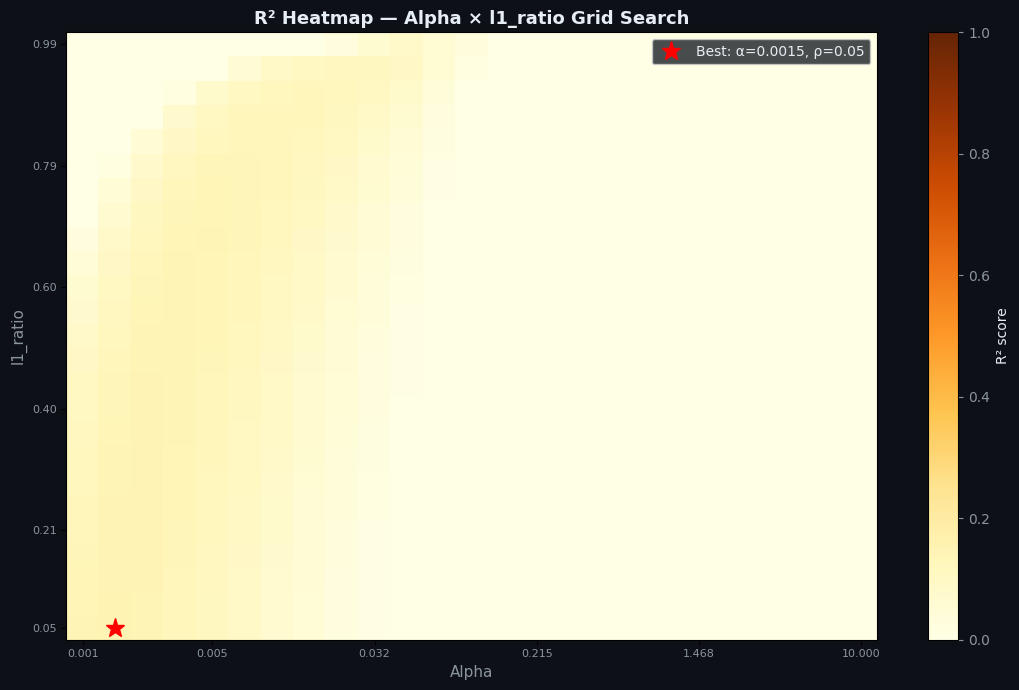

Global best  alpha    : 0.00147
Global best  l1_ratio : 0.050
Global best  R²       : 0.1490


In [11]:
# ── 2D Heatmap: R² over alpha × l1_ratio grid ────────────────────────────
alphas_grid   = np.logspace(-3, 1, 25)
l1_grid       = np.linspace(0.05, 0.99, 25)
r2_grid       = np.zeros((len(l1_grid), len(alphas_grid)))

for i, ratio in enumerate(l1_grid):
    for j, a in enumerate(alphas_grid):
        en = ElasticNet(alpha=a, l1_ratio=ratio, max_iter=5000)
        en.fit(X_train, y_train)
        r2_grid[i, j] = r2_score(y_test, en.predict(X_test))

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#0d1117')

im = ax.imshow(r2_grid, aspect='auto', origin='lower',
               cmap='YlOrBr', vmin=0, vmax=1)

# Axis ticks
x_ticks = np.linspace(0, len(alphas_grid)-1, 6, dtype=int)
y_ticks = np.linspace(0, len(l1_grid)-1, 6, dtype=int)
ax.set_xticks(x_ticks)
ax.set_xticklabels([f'{alphas_grid[i]:.3f}' for i in x_ticks], color='#8b949e', fontsize=8)
ax.set_yticks(y_ticks)
ax.set_yticklabels([f'{l1_grid[i]:.2f}' for i in y_ticks], color='#8b949e', fontsize=8)

# Mark the best cell
best_i, best_j = np.unravel_index(np.argmax(r2_grid), r2_grid.shape)
ax.plot(best_j, best_i, 'r*', markersize=14, label=f'Best: α={alphas_grid[best_j]:.4f}, ρ={l1_grid[best_i]:.2f}')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('R² score', color='#e6edf3')
cbar.ax.yaxis.set_tick_params(color='#8b949e')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')

ax.set_xlabel('Alpha', color='#8b949e', fontsize=11)
ax.set_ylabel('l1_ratio', color='#8b949e', fontsize=11)
ax.set_title('R² Heatmap — Alpha × l1_ratio Grid Search',
             color='#e6edf3', fontsize=13, fontweight='bold')
ax.legend(fontsize=10, facecolor='#1c1f26', labelcolor='#e6edf3')
plt.tight_layout()
plt.show()

print(f"Global best  alpha    : {alphas_grid[best_j]:.5f}")
print(f"Global best  l1_ratio : {l1_grid[best_i]:.3f}")
print(f"Global best  R²       : {r2_grid[best_i, best_j]:.4f}")

<div style="background: #161b22; border-left: 4px solid #f0a500; border-radius: 0 8px 8px 0; padding: 14px 18px; margin: 12px 0; font-size: 14px; color: #8b949e;">
  <strong style="color: #e6edf3;">✅ Reading the heatmap:</strong> Bright (yellow/orange) cells = high R². The red star marks the globally optimal combination. In practice, use <code>ElasticNetCV</code> to find this automatically through cross-validation instead of manual grid search.
</div>

In [12]:
# ── ElasticNetCV — automatic tuning via cross-validation ─────────────────
en_cv = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95, 0.99],
    alphas=np.logspace(-3, 1, 30),
    cv=5,
    max_iter=5000
)
en_cv.fit(X_train, y_train)

print(f"ElasticNetCV best alpha    : {en_cv.alpha_:.5f}")
print(f"ElasticNetCV best l1_ratio : {en_cv.l1_ratio_:.3f}")
print(f"ElasticNetCV R²            : {r2_score(y_test, en_cv.predict(X_test)):.4f}")

ElasticNetCV best alpha    : 0.08532
ElasticNetCV best l1_ratio : 0.990
ElasticNetCV R²            : 0.0388


<a id='summary'></a>
<div style="background: linear-gradient(135deg, #0d1117 0%, #1c1f26 100%); border: 1px solid #30363d; border-radius: 14px; padding: 36px 40px; margin-top: 32px;">
  <h2 style="color: #ffffff; font-size: 20px; font-weight: 700; margin: 0 0 8px 0;">📌 Summary &amp; When to Use ElasticNet</h2>
  <p style="color: #8b949e; font-size: 13px; margin: 0 0 20px 0;">A quick decision guide for choosing between the four regularization strategies.</p>
  <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 14px; margin-bottom: 20px;">
    <div style="background: rgba(255,255,255,0.04); border: 1px solid #30363d; border-top: 2px solid #e74c3c; border-radius: 0 0 10px 10px; padding: 16px 18px;">
      <div style="color: #e74c3c; font-weight: 700; font-size: 13px; margin-bottom: 8px;">OLS — No Regularization</div>
      <div style="color: #8b949e; font-size: 12px; line-height: 1.7;">Use when: n ≫ p, features are independent, no multicollinearity. Avoid when: many features, correlated inputs, small samples.</div>
    </div>
    <div style="background: rgba(255,255,255,0.04); border: 1px solid #30363d; border-top: 2px solid #3498db; border-radius: 0 0 10px 10px; padding: 16px 18px;">
      <div style="color: #3498db; font-weight: 700; font-size: 13px; margin-bottom: 8px;">Ridge — L2</div>
      <div style="color: #8b949e; font-size: 12px; line-height: 1.7;">Use when: most features are useful, high multicollinearity, you need all features in the model. Never produces zeros.</div>
    </div>
    <div style="background: rgba(255,255,255,0.04); border: 1px solid #30363d; border-top: 2px solid #c084fc; border-radius: 0 0 10px 10px; padding: 16px 18px;">
      <div style="color: #c084fc; font-weight: 700; font-size: 13px; margin-bottom: 8px;">Lasso — L1</div>
      <div style="color: #8b949e; font-size: 12px; line-height: 1.7;">Use when: many irrelevant features, you want automatic feature selection. Unstable with correlated features — may arbitrarily drop one from each group.</div>
    </div>
    <div style="background: rgba(240,165,0,0.07); border: 1px solid #f0a500; border-top: 2px solid #f0a500; border-radius: 0 0 10px 10px; padding: 16px 18px;">
      <div style="color: #f0a500; font-weight: 700; font-size: 13px; margin-bottom: 8px;">ElasticNet — L1 + L2 ✦ Best Default</div>
      <div style="color: #8b949e; font-size: 12px; line-height: 1.7;">Use when: correlated features + irrelevant features coexist. Combines sparsity (L1) with grouping stability (L2). Tune both α and l1_ratio with <code style='color:#f0a500;'>ElasticNetCV</code>.</div>
    </div>
  </div>
  <div style="background: rgba(255,255,255,0.03); border: 1px solid #30363d; border-radius: 8px; padding: 14px 18px; margin-bottom: 16px;">
    <div style="color: #e6edf3; font-weight: 700; font-size: 13px; margin-bottom: 8px;">⚡ Two Hyperparameters to Tune</div>
    <div style="display: grid; grid-template-columns: 1fr 1fr; gap: 10px; font-size: 12px; color: #8b949e;">
      <div><code style='color:#f0a500;'>alpha</code> — overall penalty strength. Higher → stronger regularization → simpler model.</div>
      <div><code style='color:#f0a500;'>l1_ratio</code> — L1/L2 mix. Closer to 1 → more Lasso. Closer to 0 → more Ridge. Start at 0.5, tune with CV.</div>
    </div>
  </div>
  <div style="padding-top: 14px; border-top: 1px solid #30363d; color: #8b949e; font-size: 12px;">
    Next up → <a href='https://www.kaggle.com/code/ahmedfakhar123/ml-38-logistic-regression-with-perceptron' style='text-decoration: none;'><strong style='color:#f0a500;'>ML 38: Logistic Regression with Perceptron</strong></a> — Logistic Regression intuition, Perceptron Trick, and Perceptron vs Logistic Regression.
  </div>
</div>